# Wyżarzanie kwantowe

## Model Ising w polu poprzecznym
Tutaj $\sigma^z$ oraz $\sigma^x$ to, odpowiednio, macierze Pauliego zdefiniowane jako: 

$$
\sigma^z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, \quad \sigma^x = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} 

$$ 
Warto pamiętać, że w przypadku działania macierzy Pauliego na spin zapis $\sigma^z_i$ oznacza

\begin{equation*} \sigma^z_i = I \otimes I \otimes \ldots \otimes \sigma^z \otimes I \otimes \ldots \otimes I \end{equation*}

Gdzie $\otimes$ jest iloczynem tensorowym (lub iloczynem Kroneckera)

## Twierdzenie adiabatyczne

Nie będziemy tutaj w pełni i formalnie formułować twierdzenia adiabatycznego mechaniki kwantowej. Na nasze potrzeby wystarczy rozumieć intuicyjnie.

Twierdzenie adiabatyczne (w mechanice kwantowej) z grubsza mówi, że, przy spełnieniu pewnych założeń, jeśli układ kwantowy znajduje się w stanie podstawowym pewnego hamiltonianu i ten hamiltonian zmienia się **wystarczająco powoli w czasie**, to układ pozostanie w odpowiadającym mu stanie podstawowym zmieniającego się hamiltonianu


## Sformułowanie wyżarzania kwantowego

W wyżarzaniu kwantowym wykorzystuje się to twierdzenie, aby znaleźć stan podstawowy (minimum globalne) hamiltonianu Isinga, który koduje problem optymalizacyjny. Proces wygląda tak:

1. Startujemy od prostego hamiltonianu $H_{initial}$​, którego stan podstawowy jest znany (np. prosta superpozycja).

2. Stopniowo  przekształcamy go w hamiltonian problemu $H_{problem}$​, którego minimum chcemy znaleźć.

3. Jeśli proces jest adiabatyczny (czyli wystarczająco powolny), to układ przejdzie z podstawowego stanu $H_{initial}$​ do podstawowego stanu $H_{problem}$​, dając rozwiązanie.

W maszynach D-Wave wyżarzanie kwantowe jest zaimplementowane w następujący sposób:

$$
\mathcal{H}(s) = -\frac{A(s)}{2}H_{initial} + \frac{B(s)}{2}H_{Ising} =-\frac{A(s)}{2}  \sum_{i}^{N} \sigma_i^x + \frac{B(s)}{2} ( \sum_{j < i} J_{ij} \sigma_i^z \sigma_j^z + \sum_{i=1}^{N} h_i \sigma_i^z )
$$

Gdzie $s = t/\tau$, $\tau$ to całkowity czas wyżarzania a funkcje $A(s)$ i $B(s)$ są zdefiniowane na poziomie maszyny, przy założeniu że na początku wyżarzania $A(s) \gg B(s)$, a przy zakończeniu wyżarzania $B(s) \gg A(s)$ oraz $A(s) \approx 0$.

WIP

In [12]:
# Funkcje pomocniczne które będziemy używać do robienia symulacji

import os
import qutip as qt
import pandas as pd
from typing import Optional
from math import pi

def create_spin_operators(N: int):
    #  Konstruujemy odpowiednie operatory działające na odpowiednim qubicie
    sx_list = []
    sz_list = []
    for i in range(N):
        # sigma_x/z na i-tym miejscu, na reszcze identyczności
        op_list_x = [qt.sigmax() if k==i else qt.qeye(2) for k in range(N)]
        op_list_z = [qt.sigmaz() if k==i else qt.qeye(2) for k in range(N)]
        # z listy tworzymy jedna dużą macierz (operator) przez użycie iloczynu tensorowego
        sx_list.append(qt.tensor(op_list_x))
        sz_list.append(qt.tensor(op_list_z))
    return sx_list, sz_list


def create_problem_hamiltonian(N: int, sz_list: list, J: dict, h: Optional[dict] = None):
    #  Zakłądamy że qubity są ponumerowane od 0 do N-1
    linear = sum([h[i] * sz_list[i] for i in range(N)]) if h else 0
    H_problem = linear + sum([J[(i, j)] * sz_list[i] * sz_list[j] for (i, j) in J.keys()])
    return H_problem


def load_dwave_schedule(path: os.PathLike):
    df = pd.read_excel(path, usecols=["s", "A(s) (GHz)", "B(s) (GHz)"])
    # Przejście z GHz na naturalne jednostki oraz aplikacja skalaru 1/2
    df["A(s)"] = df["A(s) (GHz)"].map(lambda x: x*pi)
    df["B(s)"] = df["B(s) (GHz)"].map(lambda x: x*pi)
    return df

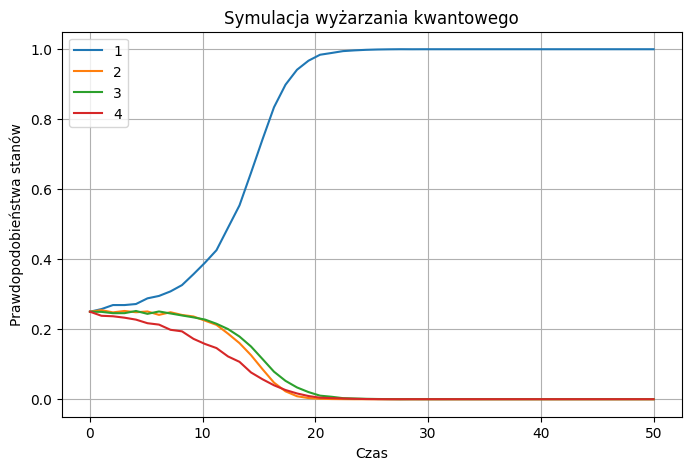

-1.5
(-1, 1)


In [28]:
# Kod do symulacji wyżarzania kwantowego. W tej symulacji ewoluujemy równanie Schrödingera 

import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import qutip as qt
from qutip.measurement import measurement_statistics
from itertools import product
from math import inf

# Rozmiar systemu
N = 2

sx_list, sz_list = create_spin_operators(N)
    

# Tworzymy  Hamiltonian początkowy H_initial 
H_initial =  -1 * sum(sx_list)


# Tworzymy hamiltonian probelmu
J = {(0, 1): 1}
h = {0: 0.5, 1: 0}
H_problem = create_problem_hamiltonian(N, sz_list, J, h)



# Czas wyżarzania w nanosekundach 
T = 50
num_steps = 50
t_list = np.linspace(0, T, num_steps, endpoint=True)

# Annealing schedules.
# Ładujemy odpowiednio odrobione dane udostępnione przez dwave
# zmienne x, a, b pozwolą nam intepolowować jeżeli dana wartość s nie występuje w danych
schedule = os.path.join("inne", "Advantage_system4_1_standard_annealing_schedule.xlsx")
df = load_dwave_schedule(schedule)
x = df["s"].to_numpy()
a = df["A(s)"].to_numpy()
b = df["B(s)"].to_numpy()


def A(t, x, a):
    s = t/T
    return np.interp(s, x, a)


def B(t, x, b):
    s = t/T
    return np.interp(s, x, b)

# Pełen hamiltonian H(t)
# H(t) = A(t)*H_initial + B(t)*H_problem
H_t = qt.QobjEvo([[H_initial, A], [H_problem, B]], args={"x": x, "a": a, "b": b})

# Przygotuj stan podstawowy dla początkowego hamiltonianiu
psi0 = H_initial.groundstate()[1]

# symulacja, sledzimy przede wszystkim prawdopodobieństwa stanów
result = qt.sesolve(H_t, psi0, t_list, options={"store_states": True})
states = result.states


energies = {}
probs = []
for state in states:
    eigenvalues, eigenstates, probabilities = measurement_statistics(state, H_problem)

    probs.append(probabilities)



plt.figure(figsize=(8, 5))
plt.plot(t_list, probs)
plt.xlabel('Czas')
plt.ylabel('Prawdopodobieństwa stanów')
plt.title('Symulacja wyżarzania kwantowego')
plt.legend(["1", "2", "3", "4"])
plt.grid(True)
plt.show()

# Stan podstawowy z bruteforce
best_energy = inf
best_state = ()
for state in product([-1, 1], repeat=N):
    
    energy = state[0] * state[1] + 0.5 * (state[0])
    if energy < best_energy:
        best_energy = energy
        best_state = state
print(best_energy)
print(best_state)


b
